# Install Libraries

In [4]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

# Engineer New Features

## 1. Average Monthly Usage

In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Asus\OneDrive\Desktop\Zaalima Project\project 1\Telco-Customer-Churn.csv")

print(df.shape)

(7043, 21)


In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)

In [14]:
df['AvgMonthlyValue'] = df['TotalCharges'] / (df['tenure'] + 1)

#### shows how much value customer generates per month

## 2. Charge vs Value Ratio

In [15]:
df['ChargeToValueRatio'] = df['MonthlyCharges'] / (df['AvgMonthlyValue'] + 1)

#### If ratio is high -> customer paying more than perceived value -> churn risk

## 3. Tenure Bucketing

In [16]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels = ['0-1yr','1-2yr','2-4yr','4-6yr'])

In [17]:
df = pd.get_dummies(df, columns=['TenureGroup'],drop_first = True)

#### Converts continuous time into behavioral segments

## 4. High Value Customer Flag

In [18]:
df['HighValueCustomer'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# Train Classification Model

## Prepare Data

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1: Logistic Regression

In [20]:
X_train.dtypes

customerID             object
gender                 object
SeniorCitizen           int64
Partner                object
Dependents             object
tenure                  int64
PhoneService           object
MultipleLines          object
InternetService        object
OnlineSecurity         object
OnlineBackup           object
DeviceProtection       object
TechSupport            object
StreamingTV            object
StreamingMovies        object
Contract               object
PaperlessBilling       object
PaymentMethod          object
MonthlyCharges        float64
TotalCharges          float64
AvgMonthlyValue       float64
ChargeToValueRatio    float64
TenureGroup_1-2yr        bool
TenureGroup_2-4yr        bool
TenureGroup_4-6yr        bool
HighValueCustomer       int64
dtype: object

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlyValue', 'ChargeToValueRatio', 'TenureGroup_1-2yr',
       'TenureGroup_2-4yr', 'TenureGroup_4-6yr', 'HighValueCustomer',
       ...
       'StreamingTV_Yes', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object', length=7079)


In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

## Model 2: Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Model 3: XGBoost

In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# Model Evaluation

## Metrics Code

In [32]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))

print("Random Forest:\n", classification_report(y_test, y_pred_rf))

print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

Logistic Regression:
               precision    recall  f1-score   support

       False       0.80      0.95      0.87      1036
        True       0.73      0.35      0.47       373

    accuracy                           0.79      1409
   macro avg       0.77      0.65      0.67      1409
weighted avg       0.78      0.79      0.77      1409

Random Forest:
               precision    recall  f1-score   support

       False       0.83      0.93      0.87      1036
        True       0.69      0.47      0.56       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

XGBoost:
               precision    recall  f1-score   support

       False       0.84      0.90      0.87      1036
        True       0.65      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79   

#### INSIGHT: Precision → Of predicted churn, how many actually churned
#### Recall → Of actual churn, how many we caught
#### F1-score → Balance of both

# SHAP 

## Install

In [33]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## SHAP Code (XGBoost)

In [34]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

## Global Feature Importance

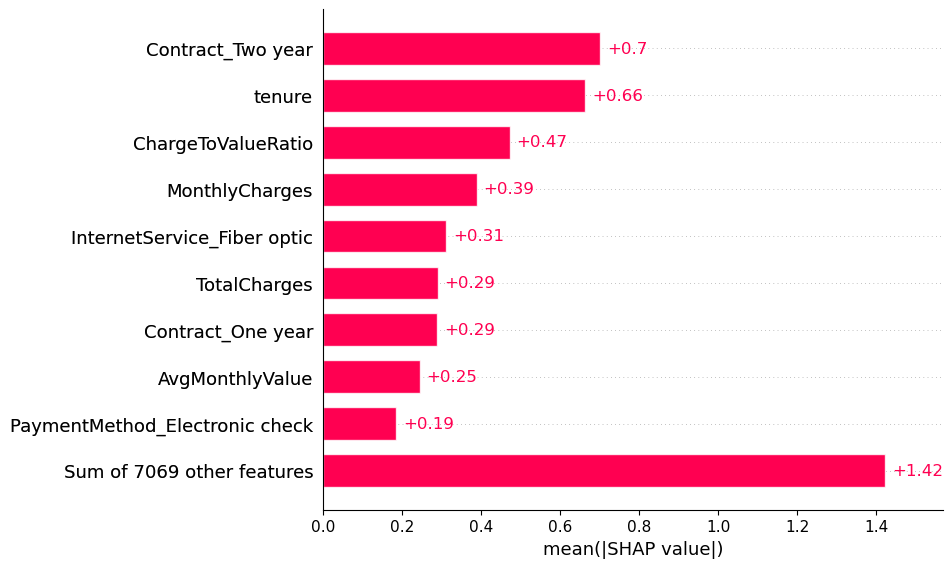

In [36]:
shap.plots.bar(shap_values)

#### Shows most important features overall

## Detailed Impact Plot

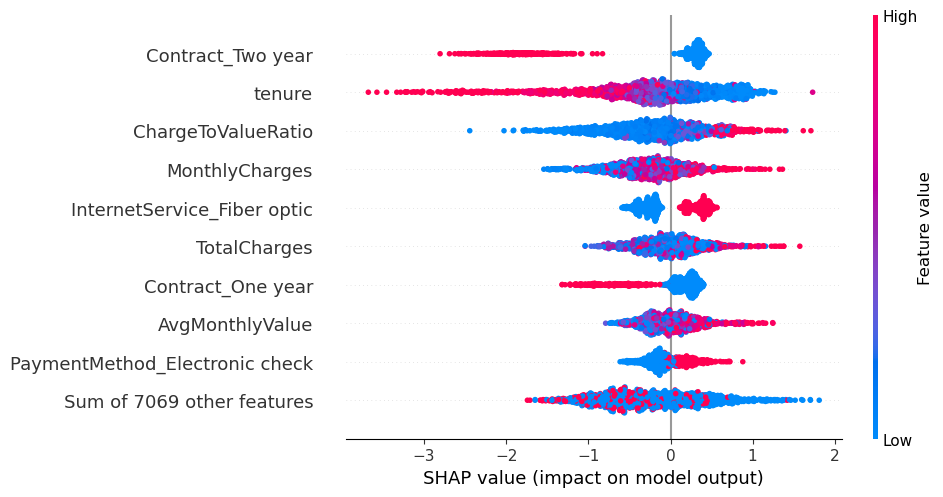

In [37]:
shap.plots.beeswarm(shap_values)

#### Shows how features push churn increase or decrease

## Individual Prediction Explanation

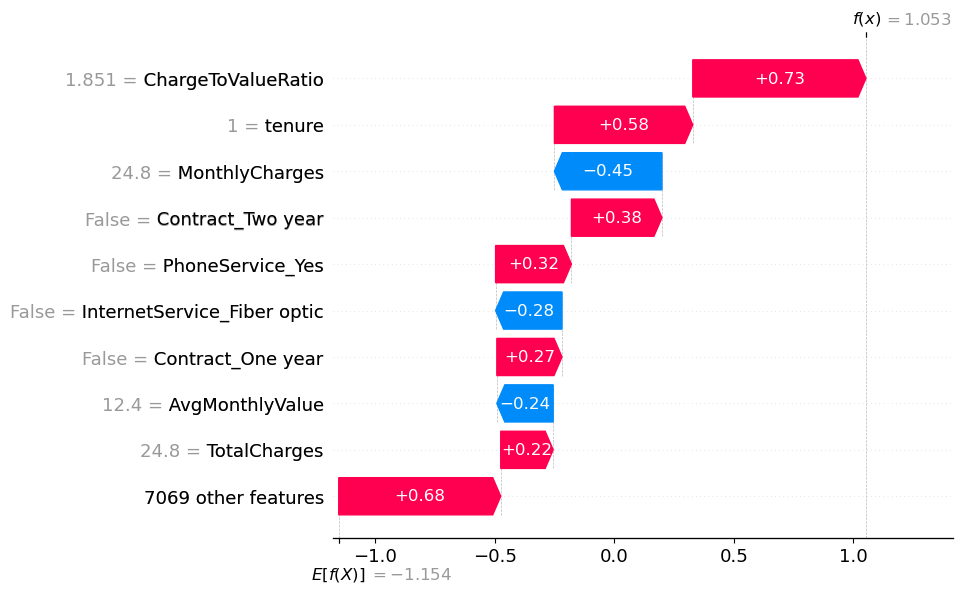

In [38]:
shap.plots.waterfall(shap_values[0])